# 从一个候选方案到完整预算—负荷倍率前沿
## MP1、MP2、连续子问题与 Benders：可运行的学习笔记

本 notebook 按“**问题是什么 → 一次怎么求 → 为什么能停 → 多次怎么连起来 → 如何独立核验**”组织。
公式、逐轮表格和图都对应实际运行的代码；图中的迭代次数不预先写死。

| 你的问题 | 阅读位置 | 运行后会看到什么 |
|---|---|---|
| MP1 + 子问题是不是 Benders，怎么收敛？ | 第 2、3 节 | 固定倍率的最低费用、完整迭代表、上下界与违反量图、第一条割的数值推导 |
| MP2 + 子问题怎么求？ | 第 4 节 | 固定预算的最大倍率、完整迭代表、上下界闭合图 |
| MP1 + MP2 + 子问题如何交替？ | 第 5 节 | 7 轮外层递推、每次内层调用、共享割池时间线和逐次查询的收敛图 |
| 真实台阶怎么检查，是扫描/ε-约束法吗？ | 第 6、7 节 | 不漏台阶的理由、216 方案独立枚举、跳点左右检查、粗扫描漏点反例 |

**编号沿用 README：MP1 = 固定 $\lambda$ 最小化费用；MP2 = 固定 $B$ 最大化 $\lambda$。**
外层从高预算开始，所以实际调用顺序是 **MP2 → MP1 → MP2 → MP1 …**。

这是四节点合成教学模型：固定功率因数、无损有功平衡、线性平方电压，不含 AC 复核、道路阻断或鲁棒负荷。
这里的“真实/精确前沿”指**这个有限整数线性模型、给定搜索范围和数值容差内**的前沿。

建议先“重启内核并运行全部”，再修改下方两个查询参数重跑。需要 `requirements.txt` 中的依赖和可用 Gurobi 许可证。
当前保存的内核为本机 `methods`；其他电脑请选择装有这些依赖的 Python 内核。

In [1]:
from pathlib import Path
import json
import math
import inspect
import html
import sys
import platform

import gurobipy as gp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from IPython.display import display, Markdown, HTML

from planning_domain_demo import (
    DemoConfig, build_model, build_master, evaluate_design, feasibility_oracle,
    solve_by_cuts, discover_frontier_by_cuts, enumerate_designs, frontier_table,
    validate_cuts, run_experiment, convex_hull_cost,
)
from plot_demo import plot_network

# 两个独立实验都从空割池开始；交替实验也使用独立空割池。
MP1_TARGET_LAMBDA = 1.3
MP2_BUDGET_CNY = 33000.0
config = DemoConfig()
model = build_model(config)
OUTPUT = Path('notebook_results') / 'learning'
FIGURES = OUTPUT / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)
pd.set_option('display.max_columns', 18)
pd.set_option('display.max_colwidth', 70)
plt.rcParams.update({
    'font.sans-serif': ['Microsoft YaHei', 'SimHei', 'DejaVu Sans'],
    'axes.unicode_minus': False, 'font.size': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
    'figure.dpi': 110, 'savefig.dpi': 180, 'pdf.fonttype': 42,
})
BLUE, ORANGE, GREEN, GRAY = '#246A8A', '#B45D27', '#357B60', '#7D858B'
print('Python:', platform.python_version(), '| Gurobi:', '.'.join(map(str, gp.gurobi.version())))
print('输出目录:', OUTPUT.resolve())

Set parameter WLSAccessID


Set parameter WLSSecret


Set parameter LicenseID to value 2685996


Academic license 2685996 - for non-commercial use only - registered to 20___@mail.scut.edu.cn


Python: 3.13.13 | Gurobi: 13.0.2
输出目录: C:\Users\10856\Desktop\GithubProject\PlanRegion\notebook_results\learning


## 1. 先认清原问题：建设方案 $x$ 与运行状态 $w$

节点 0 是电源，节点 1/2/3 的基准负荷为 25/20/15 kW，实际负荷统一乘以 $\lambda$。
从 5 条候选走廊中选 3 条组成根连通生成树；每条选中边再选 L/M/H 线型。
保留现有 L 型免费，换线按全长计费，新走廊另加施工费。图中位置只表达拓扑。

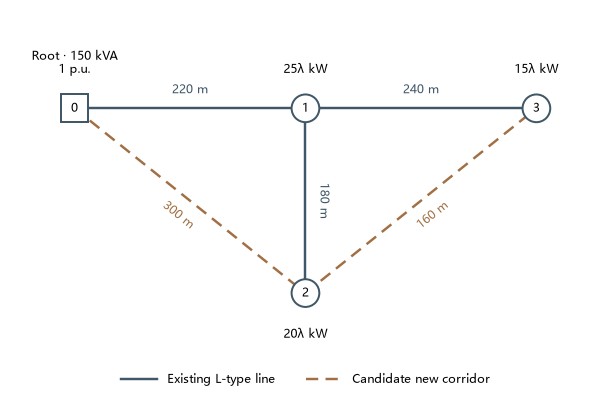

,name,start,end,length_m,existing
0,01,0,1,220.0,True
1,12,1,2,180.0,True
2,13,1,3,240.0,True
3,02,0,2,300.0,False
4,23,2,3,160.0,False


,name,r_ohm_km,x_ohm_km,capacity_kw,cable_cny_m
0,L,1.15,0.08,35.0,28.0
1,M,0.62,0.08,65.0,43.0
2,H,0.32,0.08,100.0,65.0


,L 费用/CNY,M 费用/CNY,H 费用/CNY
01,0.0,9460.0,14300.0
12,0.0,7740.0,11700.0
13,0.0,10320.0,15600.0
02,21900.0,26400.0,33000.0
23,11680.0,14080.0,17600.0


In [2]:
fig = plot_network(model, FIGURES)
plt.show()
display(pd.DataFrame([vars(e) for e in model.corridors]))
display(pd.DataFrame([vars(t) for t in model.lines]))
display(pd.DataFrame(model.cost.reshape(len(model.corridors), len(model.lines)),
                     index=[e.name for e in model.corridors],
                     columns=[f'{t.name} 费用/CNY' for t in model.lines]))

| 符号 | 含义 | 留在哪个问题中？ |
|---|---|---|
| $x_{ek}\in\{0,1\}$ | 走廊 $e$ 是否选线型 $k$，共 15 个二元变量 | MP1、MP2 |
| $X_{tree}$ | 每条边至多一种线型、恰选 3 条边、根连通 | MP1、MP2 |
| $C(x)=c^Tx$ | 新增建设费，元 | MP1 的目标 / MP2 的预算约束 |
| $\lambda$ | 所有节点同比例增加的负荷倍率 | MP1 中固定 / MP2 中优化 |
| $w=(P_{01},P_{12},P_{13},P_{02},P_{23},v_1,v_2,v_3)$ | 带符号有功潮流、非根节点平方电压 | 连续 LP 子问题 |
| $\eta\ge0$ | 为检查可行性而引入的统一违反量 | 仅子问题；原规划要求 $\eta=0$ |
| $B$ | 可用预算上限；通常大于实际费用 $C(x)$ | 外部查询参数 |

完整电气约束可统一写为
$$Ww\le h+Tx+d\lambda,\qquad x\in X_{tree},\qquad 0\le\lambda\le\lambda_{search}.$$

它包含线路容量、有功平衡、平方电压上下限、配变容量和选中线型的压降等式。
默认 $W\in\mathbb R^{53\times8}$；**所有连续变量的界也写进这 53 行**，对偶时不遗漏常数项。
费用在求解器内以千元缩放，以下结果表统一恢复为元。

两个价值函数是
$$C^*(\bar\lambda)=\min\{C(x):x\in X_{tree},\ \exists w,\ Ww\le h+Tx+d\bar\lambda\},$$
$$\Lambda^*(\bar B)=\max\{\lambda:x\in X_{tree},\ C(x)\le\bar B,\ \exists w,\ Ww\le h+Tx+d\lambda\}.$$

预算域为 $\mathcal P=\{(B,\lambda):\lambda\le\Lambda^*(B)\}$。
这里 $\lambda_{search}=3$，而配变给出物理上界 $150\times0.95/60=2.375$，所以默认搜索上界不会截断前沿。
逐行电气约束与矩阵展开可对照 [README](README.md) 的第 1–3 节。

In [3]:
display(pd.DataFrame({
    '对象': ['x', 'w', 'W', 'T', '配变倍率上界', '搜索倍率上界'],
    '大小或数值': [model.nx, model.W.shape[1], str(model.W.shape), str(model.T.shape),
                   model.transformer_limit, config.lambda_search_max],
}))
assert model.W.shape == (53, 8)
assert config.lambda_search_max >= model.transformer_limit

,对象,大小或数值
0,x,15
1,w,8
2,W,"(53, 8)"
3,T,"(53, 15)"
4,配变倍率上界,2.375
5,搜索倍率上界,3.0


## 2. 两个主问题共用的 SP：只对连续电气问题取对偶

主问题暂时不带全部电气状态，只保留整数建设、查询条件和已知割。它给出候选 $(\bar x,\bar\lambda)$，交给
$$\mathrm{SP}(\bar x,\bar\lambda):\quad
\nu=\min_{w,\eta\ge0}\eta\quad\text{s.t.}\quad
Ww\le h+T\bar x+d\bar\lambda+r\eta.$$

功率行用总基准负荷 60 kW 缩放，电压行用 $1-0.93^2=0.1351$ 缩放，因此 $\eta$ 是无量纲的统一违反量。
$\nu\le10^{-8}$ 时接受；$\nu>10^{-8}$ 时产生割。正违反量表示**当前倍率下这份建设方案不可行**，不表示这份方案在所有倍率下都不可行。

记 $b=h+Tx+d\lambda$。拉格朗日函数为
$$L=\eta+\pi^T(Ww-b-r\eta).$$
对自由变量 $w$ 与非负变量 $\eta$ 取下确界，得到
$$\nu=\max_{\pi\in\Pi}-\pi^Tb,\qquad
\Pi=\{\pi\ge0:W^T\pi=0,\ r^T\pi\le1\}.$$
于是每个对偶解都给出必要条件
$$g_t(x,\lambda)=\pi_t^T(h+Tx+d\lambda)\ge0.$$
在产生它的候选点处，强对偶给出 $g_t(\bar x,\bar\lambda)=-\nu<0$，所以新割确实排除当前错误候选。
对任何真正可行点，$Ww\le b$ 且 $\pi\ge0$ 推出 $0=\pi^TWw\le\pi^Tb$，所以它不会误删可行点。

**这是以可行性割为核心的 Benders 分解。** 原问题没有运行费用目标，因而无需用 $\theta$ 和最优性割近似第二阶段费用。
弹性 SP 本身始终可求；我们从它的正最优违反量生成原电气问题的可行性割，不能把“SP 返回 optimal”误读成原候选可行。
Gurobi 对最小化 LP 的 `<=` 行给出 `Pi <= 0`，代码用 $\pi=-\mathrm{Pi}$。

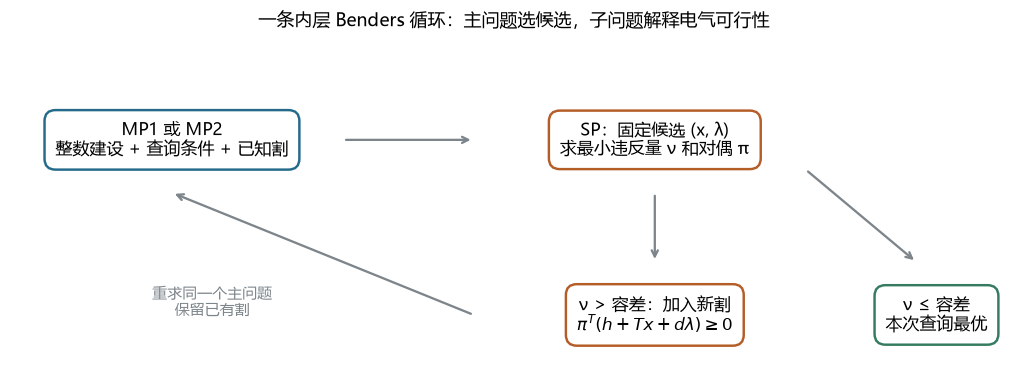

In [4]:
def save_learning_figure(fig, name):
    fig.savefig(FIGURES / f'{name}.png', bbox_inches='tight')
    fig.savefig(FIGURES / f'{name}.pdf', bbox_inches='tight')

fig, ax = plt.subplots(figsize=(11.8, 3.9))
ax.set(xlim=(0, 1), ylim=(0, 1))
ax.axis('off')
boxes = [
    ((.16, .73), 'MP1 或 MP2\n整数建设 + 查询条件 + 已知割', BLUE),
    ((.64, .73), 'SP：固定候选 (x, λ)\n求最小违反量 ν 和对偶 π', ORANGE),
    ((.64, .20), 'ν > 容差：加入新割\n' + r'$\pi^T(h + Tx + d\lambda)\geq0$', ORANGE),
    ((.92, .20), 'ν ≤ 容差\n本次查询最优', GREEN),
]
for (x, y), label, color in boxes:
    ax.text(x, y, label, ha='center', va='center', fontsize=11,
            bbox=dict(boxstyle='round,pad=.65', fc='white', ec=color, lw=1.6))
for start, end in [((.33,.73),(.46,.73)), ((.64,.57),(.64,.36)),
                   ((.79,.64),(.9,.36)), ((.46,.2),(.16,.57))]:
    ax.annotate('', xy=end, xytext=start,
                arrowprops=dict(arrowstyle='->', color=GRAY, lw=1.5))
ax.text(.20,.20,'重求同一个主问题\n保留已有割', ha='center', color=GRAY)
ax.set_title('一条内层 Benders 循环：主问题选候选，子问题解释电气可行性', pad=16)
save_learning_figure(fig, '01_benders_flow')
plt.show()

下面先定义共用的展示函数，随后每个实验都独立执行。表中 `cut_count_before` 是本轮求解前的割数，
`cut_count_after` 是本轮处理后的割数；**一次主问题求解不一定新增割**，最终接受轮不加割。
下界和上界都是本次查询目标的界，MP1 的单位是元，MP2 的单位是倍率。

In [5]:
def show_trace(result):
    columns = ['iteration', 'cut_count_before', 'candidate_cost_cny', 'candidate_lambda',
               'design_capacity', 'violation', 'lower_bound', 'upper_bound',
               'absolute_gap', 'cut_id', 'action', 'design']
    names = ['内层轮次', '已有割数', '候选费用/元', '候选倍率', '该方案可达倍率',
             'SP违反量', '目标下界', '目标上界', '绝对间隙', '新增割编号', '处理', '候选方案']
    table = result.trace[columns].copy()
    table.columns = names
    table['处理'] = table['处理'].replace({
        'add_cut': '加割后重求', 'accept': '可行，结束', 'master_infeasible': '主问题不可行，结束'})
    with pd.option_context('display.max_rows', None):
        display(table)

def plot_query_convergence(result, title, filename):
    trace = result.trace[result.trace.master_status == 'optimal']
    t = trace.iteration.to_numpy()
    divisor = 1000 if result.mode == 'min_cost' else 1
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), layout='constrained')
    ax = axes[0]
    ax.plot(t, trace.lower_bound/divisor, 'o-', color=BLUE, label='LB：目标下界')
    finite_upper = trace.upper_bound.where(np.isfinite(trace.upper_bound)) / divisor
    ax.plot(t, finite_upper, 's--', color=ORANGE, label='UB：目标上界（仅绘有限值）')
    if np.isinf(trace.upper_bound).any():
        ax.text(.03, .96, '找到首个可行方案之前：UB = +∞', transform=ax.transAxes,
                ha='left', va='top', fontsize=9, color=ORANGE,
                bbox=dict(facecolor='white', alpha=.9, edgecolor='none'))
    ax.set(xlabel='内层主问题求解轮次 k', ylabel='建设费 / 千元' if divisor == 1000 else '负荷倍率 λ',
           title='a  本次查询的目标上下界')
    ax.legend(loc='lower right', fontsize=9)
    ax = axes[1]
    ax.plot(t, trace.violation, 'o-', color=ORANGE, label='真实 SP 违反量 ν')
    ax.axhline(config.feasibility_tolerance, color=GREEN, ls='--', label='接受阈值 1e-8')
    accepted = trace.action == 'accept'
    ax.scatter(t[accepted], trace.violation[accepted], marker='*', s=150, color=GREEN,
               zorder=5, label='接受候选')
    ax.set(yscale='symlog', xlabel='内层主问题求解轮次 k', ylabel='最小违反量 ν（含 0 的对称对数轴）',
           title='b  子问题判断及停止位置')
    ax.set_yscale('symlog', linthresh=1e-8)
    ax.legend(fontsize=9)
    for ax in axes:
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax.grid(alpha=.2)
    fig.suptitle(title, fontsize=13)
    save_learning_figure(fig, filename)
    plt.show()
    return fig

def check_query_trace(result):
    trace = result.trace
    optimal = trace[trace.master_status == 'optimal']
    assert np.all(np.diff(optimal.lower_bound) >= -1e-6)
    finite = optimal.upper_bound[np.isfinite(optimal.upper_bound)]
    assert np.all(np.diff(finite) <= 1e-6)
    assert np.all(optimal.lower_bound <= optimal.upper_bound+2e-6)
    assert int(trace.cut_added.sum()) == result.new_cuts
    assert np.all(trace.cut_count_after-trace.cut_count_before == trace.cut_added.astype(int))
    assert optimal.strong_duality_error.max() < 1e-7
    assert optimal.dual_stationarity_error.max() < 1e-7
    assert optimal.dual_normalization.max() <= 1+1e-7
    assert optimal.dual_min_multiplier.min() >= -1e-8
    if result.status == 'optimal':
        assert trace.iloc[-1].action == 'accept'
        assert abs(trace.iloc[-1].absolute_gap) < 2e-6
        assert trace.iloc[-1].violation <= config.feasibility_tolerance
    else:
        assert trace.iloc[-1].action == 'master_infeasible'
    return True

## 3. MP1 + SP：给定倍率，最低建设费是多少？

本节默认固定 $\bar\lambda=1.3$，空割池冷启动。第 $k$ 轮的受限主问题为
$$\mathrm{MP1}_k:\quad\min_x C(x)\quad\text{s.t.}\quad
x\in X_{tree},\ \lambda=\bar\lambda,\ g_t(x,\lambda)\ge0\ (t\in\mathcal K_k).$$

1. 先找满足树结构和已知割的最便宜候选。
2. SP 检查这个候选是否能承载指定倍率。
3. 若 $\nu>\varepsilon_{feas}$，加入电气割后重求；若可行，结束本次查询。

为什么一旦可行就能停？受限 MP1 放宽了电气约束，故其最优值给 **LB**；
通过 SP 的候选实际可实施，故其费用给 **UB**。候选已是主问题最优解，因此接受时 LB 与 UB 闭合。
本实现没有预先喂入一个可行建设方案，**首个可行候选出现前 UB 保持 $+\infty$**。

In [6]:
mp1_cuts = []
mp1 = solve_by_cuts(model, 'min_cost', MP1_TARGET_LAMBDA, mp1_cuts)
assert mp1.status == 'optimal'
assert check_query_trace(mp1)
display(Markdown(f'倍率 **{mp1.query:g}**：最低费用 **{mp1.value:,.0f} 元**；'
                 f'共 **{len(mp1.trace)}** 次主问题求解、**{mp1.new_cuts}** 条新割。'))
show_trace(mp1)
mp1.trace.to_csv(OUTPUT / 'mp1_trace.csv', index=False)

倍率 **1.3**：最低费用 **32,360 元**；共 **13** 次主问题求解、**12** 条新割。

,内层轮次,已有割数,候选费用/元,候选倍率,该方案可达倍率,SP违反量,目标下界,目标上界,绝对间隙,新增割编号,处理,候选方案
0,1,0,0.0,1.3,0.546915,0.143333,0.0,inf,inf,1.0,加割后重求,01:L; 12:L; 13:L
1,2,1,14300.0,1.3,1.227380,0.008822,14300.0,inf,inf,2.0,加割后重求,01:H; 12:L; 13:L
2,3,2,22040.0,1.3,1.227380,0.007560,22040.0,inf,inf,3.0,加割后重求,01:H; 12:M; 13:L
3,4,3,24620.0,1.3,1.227380,0.007200,24620.0,inf,inf,4.0,加割后重求,01:H; 12:L; 13:M
4,5,4,25980.0,1.3,0.730031,0.062544,25980.0,inf,inf,5.0,加割后重求,01:H; 12:L; 23:L
5,6,5,25980.0,1.3,0.593321,0.078903,25980.0,inf,inf,6.0,加割后重求,01:H; 13:L; 23:L
6,7,6,26400.0,1.3,0.740982,0.063499,26400.0,inf,inf,7.0,加割后重求,01:L; 13:L; 02:M
7,8,7,28380.0,1.3,0.798649,0.054390,28380.0,inf,inf,8.0,加割后重求,01:H; 12:L; 23:M
8,9,8,28380.0,1.3,0.654233,0.072138,28380.0,inf,inf,9.0,加割后重求,01:H; 13:L; 23:M
9,10,9,31360.0,1.3,1.089291,0.020818,31360.0,inf,inf,10.0,加割后重求,01:M; 13:L; 02:L


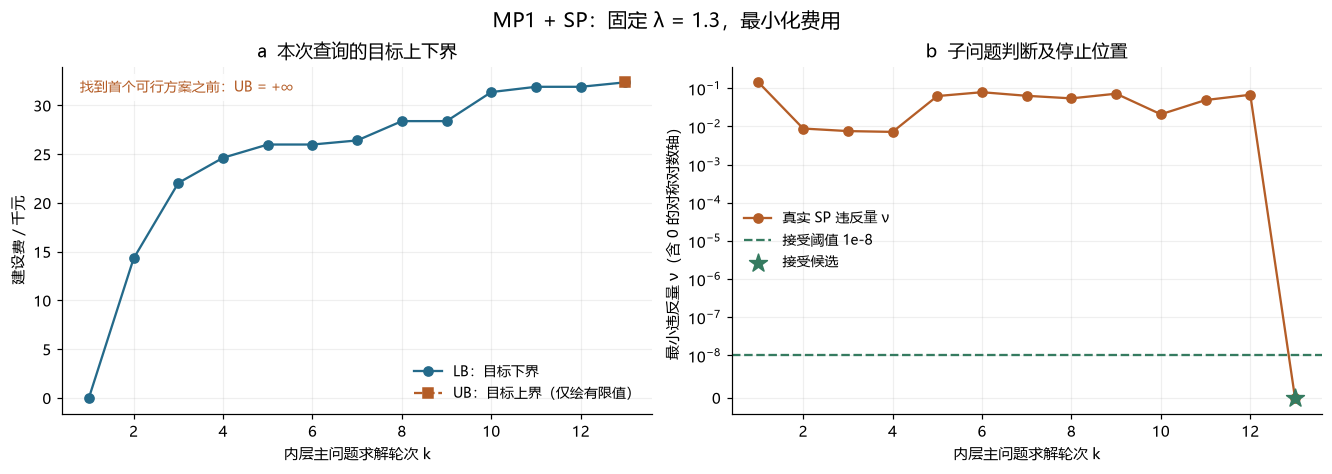

In [7]:
fig = plot_query_convergence(mp1, f'MP1 + SP：固定 λ = {mp1.query:g}，最小化费用', '02_mp1_convergence')

### 3.1 手工读懂第一条真实 LP 对偶割

下面使用上表第一轮的整数候选和刚产生的对偶乘子，不重新求解另一个模型。
先看哪些电气行的乘子非零，再把割展开成 $\beta_0+\beta_x^Tx+\beta_\lambda\lambda\ge0$。
这些乘子来自用于检查可行性的 LP，不能解释成原整数建设问题的影子价格。

In [8]:
first = mp1.trace.iloc[0]
first_cut = mp1_cuts[0]
x_first = np.array(json.loads(first.candidate_x))
active = np.flatnonzero(np.abs(first_cut.pi) > 1e-10)
display(pd.DataFrame({
    '电气行': [model.electrical_constraints[i].ConstrName for i in active],
    'π': first_cut.pi[active],
}))
names = [f'x_{{{e.name},{line.name}}}' for e in model.corridors for line in model.lines]
terms = [f'{first_cut.constant:.8g}']
terms += [f'{v:+.8g}{name}' for v, name in zip(first_cut.x_coeff, names) if abs(v)>1e-10]
terms += [f'{first_cut.lambda_coeff:+.8g}\\lambda']
display(Markdown('本轮可行性割：$$' + ' '.join(terms) + r'\ge0.$$'))
margin = first_cut.constant + first_cut.x_coeff@x_first + first_cut.lambda_coeff*first.candidate_lambda
display(pd.DataFrame({
    '核对项': ['SP最优违反量 ν', '割在产生点的值 g', '强对偶残差 |g+ν|',
               'max|Wᵀπ|', 'rᵀπ（应≤1）', 'min π（应≥0）'],
    '数值': [first.violation, margin, abs(margin+first.violation),
             np.max(np.abs(model.W.T@first_cut.pi)), model.scales@first_cut.pi, first_cut.pi.min()],
}))
assert margin < 0 and abs(margin+first.violation) < 1e-7

,电气行,π
0,capacity_01_1,0.003333
1,capacity_02_1,0.003333
2,balance_1_-1,0.003333
3,balance_2_-1,0.003333
4,balance_3_-1,0.003333


本轮可行性割：$$0 +0.11666667x_{01,L} +0.21666667x_{01,M} +0.33333333x_{01,H} +0.11666667x_{02,L} +0.21666667x_{02,M} +0.33333333x_{02,H} -0.2\lambda\ge0.$$

,核对项,数值
0,SP最优违反量 ν,0.143333
1,割在产生点的值 g,-0.143333
2,强对偶残差 |g+ν|,0.000000
3,max|Wᵀπ|,0.000000
4,rᵀπ（应≤1）,1.000000
5,min π（应≥0）,-0.000000


### 3.2 不可行时如何结束？

若目标倍率高于任何设计的能力，算法不能以一个“最便宜但电气不合格”的候选结束。
以 $\lambda=2.4>2.375$ 为例：SP 逐步排除错误候选，最终受限主问题不可行，才证明该查询无解。
终止那一轮没有 SP 求解，因此表中候选、违反量为空；这不是零违反量。

In [9]:
infeasible_cuts = []
infeasible_mp1 = solve_by_cuts(model, 'min_cost', 2.4, infeasible_cuts)
assert infeasible_mp1.status == 'infeasible'
assert check_query_trace(infeasible_mp1)
show_trace(infeasible_mp1)
infeasible_mp1.trace.to_csv(OUTPUT / 'mp1_infeasible_trace.csv', index=False)

,内层轮次,已有割数,候选费用/元,候选倍率,该方案可达倍率,SP违反量,目标下界,目标上界,绝对间隙,新增割编号,处理,候选方案
0,1,0,0.0,2.4,0.546915,0.363333,0.0,inf,inf,1.0,加割后重求,01:L; 12:L; 13:L
1,2,1,40700.0,2.4,1.484197,0.078842,40700.0,inf,inf,2.0,加割后重求,01:H; 13:L; 02:M
2,3,2,42460.0,2.4,1.089291,0.129498,42460.0,inf,inf,3.0,加割后重求,01:M; 13:L; 02:H
3,4,3,51020.0,2.4,2.011144,0.030145,51020.0,inf,inf,4.0,加割后重求,01:H; 13:M; 02:M
4,5,4,52380.0,2.4,1.124755,0.120680,52380.0,inf,inf,5.0,加割后重求,01:H; 02:M; 23:L
5,6,5,52780.0,2.4,1.348631,0.103333,52780.0,inf,inf,6.0,加割后重求,01:M; 13:M; 02:H
6,7,6,54140.0,2.4,1.673272,0.058719,54140.0,inf,inf,7.0,加割后重求,01:M; 02:H; 23:L
7,8,7,54780.0,2.4,1.296358,0.100708,54780.0,inf,inf,8.0,加割后重求,01:H; 02:M; 23:M
8,9,8,56300.0,2.4,2.375000,0.025000,56300.0,inf,inf,9.0,加割后重求,01:H; 13:H; 02:M
9,10,9,NaN,NaN,NaN,NaN,inf,inf,NaN,NaN,主问题不可行，结束,NaN


## 4. MP2 + SP：给定预算，最大负荷倍率是多少？

本节默认 $\bar B=33{,}000$ 元，重新从空割池开始，便于看清完整收敛过程。
$$\mathrm{MP2}_k:\quad\max_{x,\lambda}\lambda\quad\text{s.t.}\quad
x\in X_{tree},\ C(x)\le\bar B,\ 0\le\lambda\le3,\ g_t(x,\lambda)\ge0\ (t\in\mathcal K_k).$$

流程仍是“MP2 候选 → SP 检查 → 加割 / 接受”，但目标方向相反：
受限 MP2 的最优目标界给 **UB**，预算内实际可行的倍率给 **LB**。

本例的 LB 有一个额外的便捷来源：对主问题**已经选出的那一棵树**，沿树累计下游负荷、线路容量和路径压降，
即可解析计算它的最大倍率 $\Lambda(x)$；取历次候选的最大值为 LB。
这是 `evaluate_design` 对单个候选的电气校核，**没有枚举全部方案，也不用于产生割**。
即使候选 $\bar\lambda$ 过大，这棵树在较低的 $\Lambda(x)$ 处仍可行，因此中途可以得到有用 LB。
通用大系统中可用固定设计的运行优化求这个可行界。

注意：UB 单调不增，LB 单调不减；**不同候选的违反量不要求单调下降**。

In [10]:
mp2_cuts = []
mp2 = solve_by_cuts(model, 'max_lambda', MP2_BUDGET_CNY, mp2_cuts)
assert mp2.status == 'optimal'
assert check_query_trace(mp2)
display(Markdown(f'预算 **{mp2.query:,.0f} 元**：最大倍率 **{mp2.value:.9f}**；'
                 f'共 **{len(mp2.trace)}** 次主问题求解、**{mp2.new_cuts}** 条新割。'))
show_trace(mp2)
mp2.trace.to_csv(OUTPUT / 'mp2_trace.csv', index=False)

预算 **33,000 元**：最大倍率 **1.566887427**；共 **11** 次主问题求解、**10** 条新割。

,内层轮次,已有割数,候选费用/元,候选倍率,该方案可达倍率,SP违反量,目标下界,目标上界,绝对间隙,新增割编号,处理,候选方案
0,1,0,0.0,3.000000,0.546915,0.625000,0.546915,3.000000,2.453085e+00,1.0,加割后重求,01:L; 12:L; 13:L
1,2,1,0.0,2.375000,0.546915,0.358333,0.546915,2.375000,1.828085e+00,2.0,加割后重求,01:L; 12:L; 13:L
2,3,2,33000.0,2.250000,0.740982,0.183333,0.740982,2.250000,1.509018e+00,3.0,加割后重求,01:L; 13:L; 02:H
3,4,3,14300.0,1.666667,1.227380,0.053365,1.227380,1.666667,4.392870e-01,4.0,加割后重求,01:H; 12:L; 13:L
4,5,4,31900.0,1.666667,0.694597,0.112091,1.227380,1.666667,4.392870e-01,5.0,加割后重求,01:H; 13:L; 23:H
5,6,5,24620.0,1.666667,1.227380,0.043551,1.227380,1.666667,4.392870e-01,6.0,加割后重求,01:H; 12:L; 13:M
6,7,6,26000.0,1.666667,1.227380,0.045732,1.227380,1.666667,4.392870e-01,7.0,加割后重求,01:H; 12:H; 13:L
7,8,7,32360.0,1.666667,1.566887,0.010981,1.566887,1.666667,9.977924e-02,8.0,加割后重求,01:H; 12:M; 13:M
8,9,8,31900.0,1.666667,0.843528,0.090240,1.566887,1.666667,9.977924e-02,9.0,加割后重求,01:H; 12:L; 23:H
9,10,9,31360.0,1.625000,1.089291,0.055481,1.566887,1.625000,5.811257e-02,10.0,加割后重求,01:M; 13:L; 02:L


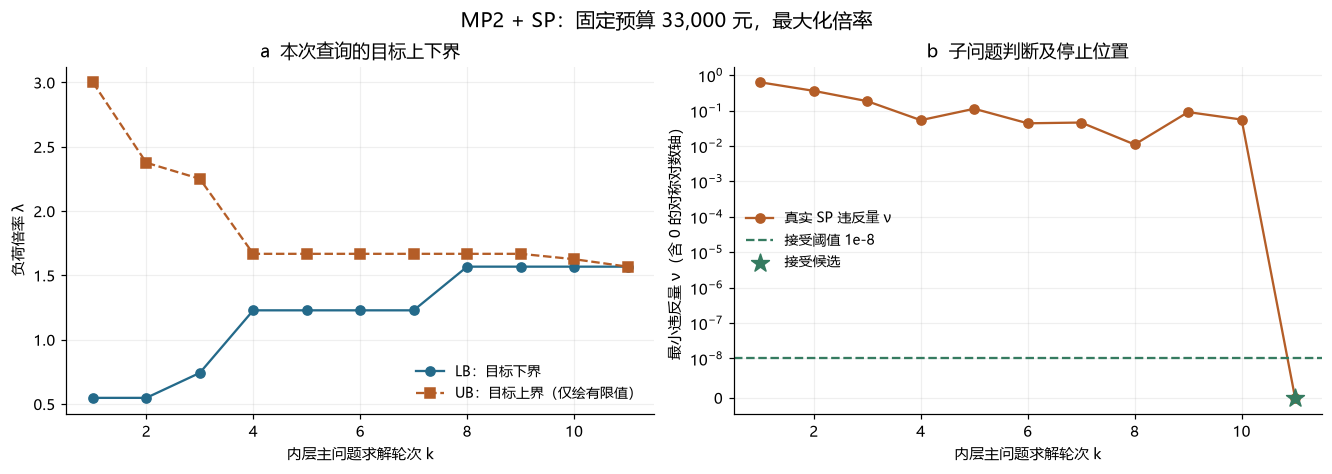

In [11]:
fig = plot_query_convergence(mp2, f'MP2 + SP：固定预算 {mp2.query:,.0f} 元，最大化倍率', '03_mp2_convergence')

### 4.1 读出最终可行解的潮流与电压

再次把最后的 $(x,\lambda)$ 传给 SP，下面显示求解器实际得到的运行状态。
SP 的目标只有 $\eta$，所以潮流/电压可能有数值上的多解；它们必须满足所报告的电气约束。

In [12]:
final_violation, _ = feasibility_oracle(model, mp2.x, mp2.lambda_value)
flow_values = [model.subproblem.getVarByName(f'P[{e}]').X for e in range(len(model.corridors))]
voltages = [1.0] + [model.subproblem.getVarByName(f'v[{i}]').X for i in range(1,4)]
w_final = np.array(flow_values + voltages[1:])
max_residual = np.max(model.W@w_final-model.h-model.T@mp2.x-model.d*mp2.lambda_value)
display(pd.DataFrame({'走廊参考方向': [f'{e.start}→{e.end}' for e in model.corridors],
                      '有功潮流/kW': flow_values}))
display(pd.DataFrame({'节点': range(4), '平方电压 v': voltages, '电压/p.u.': np.sqrt(voltages)}))
print('SP违反量:', final_violation, '| 未松弛电气行最大残差:', max_residual)
assert final_violation <= config.feasibility_tolerance and max_residual < 1e-6

,走廊参考方向,有功潮流/kW
0,0→1,94.013246
1,1→2,31.337749
2,1→3,23.503311
3,0→2,0.000000
4,2→3,0.000000


,节点,平方电压 v,电压/p.u.
0,0,1.00000,1.000000
1,1,0.91047,0.954186
2,2,0.86490,0.930000
3,3,0.86490,0.930000


SP违反量: 0.0 | 未松弛电气行最大残差: 7.105427357601002e-15


## 5. MP2 + MP1 + SP：两层循环如何配合？

**内层 $k$：**一次固定预算/倍率查询中的 Benders 循环，收紧这个查询的目标界。
**外层 $j$：**依次发现不同的前沿拐点，预算、倍率均会改变，不能把这些不同目标的数值接成一条“全局 LB/UB”曲线。

设当前预算为 $B_j$，使用同一个只增不减的割池：

$$\boxed{B_j\ \xrightarrow{\mathrm{MP2+SP}}\ \lambda_j=\Lambda^*(B_j)
\ \xrightarrow{\mathrm{MP1+SP}}\ C_j=C^*(\lambda_j)
\ \xrightarrow{\text{记录前沿点}}\ (C_j,\lambda_j)
\ \xrightarrow{B_{j+1}=C_j-\delta_C}\ \text{下一轮}}$$

MP2 负责“这个预算最多能承载多少”；MP1 负责“承载同样多，究竟最少要花多少”。
**同一个最优倍率可能由多份费用不同的方案实现**，因此必须做 MP1 的费用压缩，才能定位台阶左端。
MP1 固定的是 $\lambda_j$，并不要求它选择的设计恰好以 $\lambda_j$ 为物理极限。
固定达到该倍率即可；在本轮预算最优性的保证下，费用压缩后不能出现更高倍率的遗漏前沿。

这里两者是同一可行域上的两个不同标量查询，整体是**外层 ε-约束递推 + 内层 Benders**，
不是把 MP1 和 MP2 当成互为对偶的问题，也不是两个主问题互相传递“目标函数割”。
能共享电气割，是因为 $W,h,T,d,r$ 没有变化；预算和查询目标不出现在对偶可行集合 $\Pi$ 中。
若换了电气参数、候选线路或变量含义，必须重建模型并清空割池。

In [13]:
shared_cuts, query_history, round_history = [], [], []
recovered = discover_frontier_by_cuts(
    model, shared_cuts, query_history=query_history, round_history=round_history)
outer = pd.DataFrame(round_history)
query_rows, trace_parts = [], []
for i, result in enumerate(query_history, start=1):
    phase = 'MP2' if result.mode == 'max_lambda' else 'MP1'
    outer_round = (i+1)//2
    assert check_query_trace(result)
    part = result.trace.copy()
    part['cut_id'] = part['cut_id'].astype(float)  # 无新增割的查询也采用同一数值列类型。
    part.insert(0, 'phase', phase)
    part.insert(0, 'outer_round', outer_round)
    part.insert(0, 'query_number', i)
    trace_parts.append(part)
    query_rows.append({
        'query_number': i, 'outer_round': outer_round, 'phase': phase,
        'query': result.query, 'query_unit': 'CNY' if phase == 'MP2' else 'lambda',
        'value': result.value, 'value_unit': 'lambda' if phase == 'MP2' else 'CNY',
        'master_solves': len(result.trace), 'new_cuts': result.new_cuts,
        'inherited_cuts': int(result.trace.iloc[0].cut_count_before), 'status': result.status,
    })
queries = pd.DataFrame(query_rows)
combined_trace = pd.concat(trace_parts, ignore_index=True)
combined_trace.insert(0, 'global_iteration', np.arange(1, len(combined_trace)+1))
outer.to_csv(OUTPUT / 'alternating_rounds.csv', index=False)
queries.to_csv(OUTPUT / 'alternating_queries.csv', index=False)
combined_trace.to_csv(OUTPUT / 'alternating_all_iterations.csv', index=False)
recovered.to_csv(OUTPUT / 'recovered_frontier.csv', index=False)
print(f'从空割池恢复 {len(recovered)} 个台阶；{len(queries)} 次查询；'
      f'{len(combined_trace)} 次主问题求解；{len(shared_cuts)} 条共享割。')
display(outer.rename(columns={
    'outer_round':'外层轮次', 'budget_cny':'输入预算', 'mp2_lambda':'MP2最优倍率',
    'mp2_design_cost_cny':'MP2返回方案费用', 'mp1_cost_cny':'MP1最低费用',
    'next_budget_cny':'下一预算', 'quantum_cny':'费用粒度',
    'mp2_iterations':'MP2内层次数', 'mp1_iterations':'MP1内层次数',
    'mp2_new_cuts':'MP2新割', 'mp1_new_cuts':'MP1新割',
    'cuts_before':'轮前割数', 'cuts_after':'轮后割数', 'design':'最终方案',
}))

从空割池恢复 7 个台阶；14 次查询；51 次主问题求解；37 条共享割。


,外层轮次,输入预算,MP2最优倍率,MP2返回方案费用,MP1最低费用,下一预算,费用粒度,MP2内层次数,MP1内层次数,MP2新割,MP1新割,轮前割数,轮后割数,最终方案
0,1,193780.0,2.375000,62900.0,56300.0,56280.0,20,5,6,4,5,0,9,01:H; 13:H; 02:M
1,2,56280.0,2.011144,51020.0,51020.0,51000.0,20,5,1,4,0,9,13,01:H; 13:M; 02:M
2,3,51000.0,1.666667,41600.0,41600.0,41580.0,20,17,6,16,5,13,34,01:H; 12:H; 13:H
3,4,41580.0,1.566887,37640.0,32360.0,32340.0,20,2,1,1,0,34,35,01:H; 12:M; 13:M
4,5,32340.0,1.227380,26000.0,14300.0,14280.0,20,1,1,0,0,35,35,01:H; 12:L; 13:L
5,6,14280.0,0.846640,9460.0,9460.0,9440.0,20,2,1,1,0,35,36,01:M; 12:L; 13:L
6,7,9440.0,0.546915,7740.0,0.0,-20.0,20,2,1,1,0,36,37,01:L; 12:L; 13:L


### 5.1 外层轨迹：每轮如何找到台阶左端

左图的“×”是 MP2 返回方案的费用与能力；同一水平的“○”是 MP1 压缩后的费用与能力。
横线表示费用压缩，数字是发现次序。背景台阶此时只由算法恢复的点画出，下一节才引入独立真值。
右图是各轮预算和最低费用；下一轮预算来自**最低费用减 20**，不是输入预算减 20。

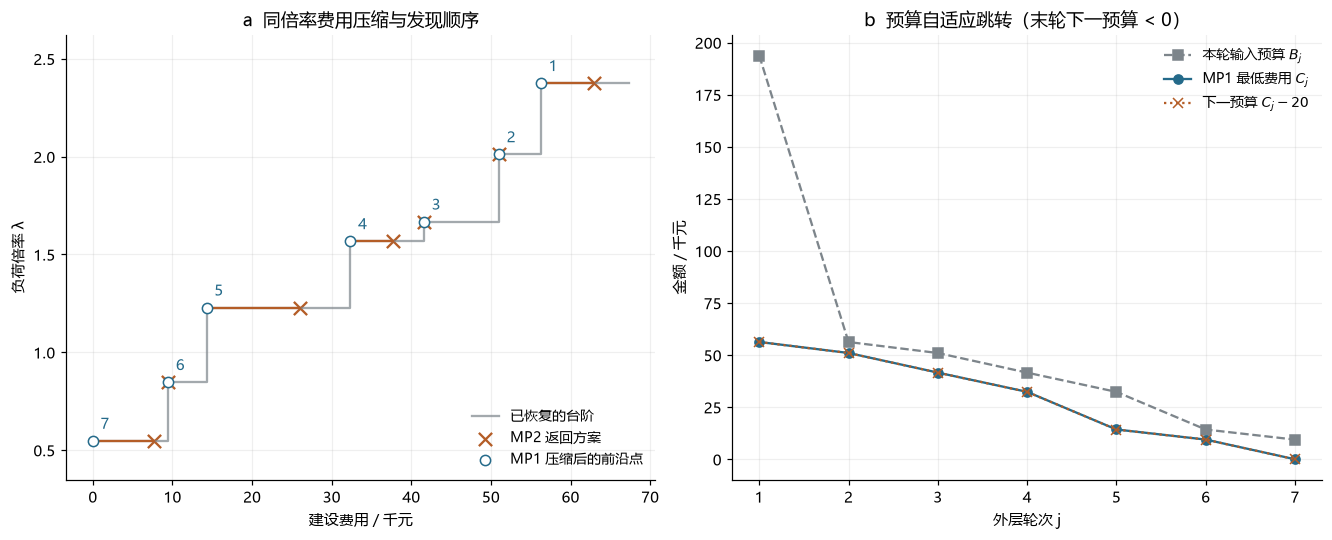

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), layout='constrained')
ax = axes[0]
end_budget = max(recovered.cost_cny.max(), outer.mp2_design_cost_cny.max()) * 1.07
ax.step(np.r_[recovered.cost_cny, end_budget]/1000,
        np.r_[recovered.lambda_max, recovered.lambda_max.iloc[-1]], where='post',
        color=GRAY, alpha=.7, label='已恢复的台阶')
for row in outer.itertuples():
    ax.plot([row.mp1_cost_cny/1000, row.mp2_design_cost_cny/1000], [row.mp2_lambda]*2, color=ORANGE)
    ax.annotate(str(row.outer_round), (row.mp1_cost_cny/1000, row.mp2_lambda),
                xytext=(5, 8), textcoords='offset points', color=BLUE)
ax.scatter(outer.mp2_design_cost_cny/1000, outer.mp2_lambda, marker='x', s=75,
           color=ORANGE, label='MP2 返回方案')
ax.scatter(outer.mp1_cost_cny/1000, outer.mp2_lambda, marker='o', facecolors='white',
           edgecolors=BLUE, s=45, label='MP1 压缩后的前沿点', zorder=4)
ax.set(xlabel='建设费用 / 千元', ylabel='负荷倍率 λ', title='a  同倍率费用压缩与发现顺序', ylim=(.35,2.62))
ax.legend(fontsize=9, loc='lower right')
ax = axes[1]
ax.plot(outer.outer_round, outer.budget_cny/1000, 's--', color=GRAY, label=r'本轮输入预算 $B_j$')
ax.plot(outer.outer_round, outer.mp1_cost_cny/1000, 'o-', color=BLUE, label=r'MP1 最低费用 $C_j$')
ax.plot(outer.outer_round, outer.next_budget_cny/1000, 'x:', color=ORANGE, label=r'下一预算 $C_j - 20$')
ax.set(xlabel='外层轮次 j', ylabel='金额 / 千元', title='b  预算自适应跳转（末轮下一预算 < 0）')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.legend(fontsize=9)
for ax in axes: ax.grid(alpha=.2)
save_learning_figure(fig, '04_alternating_frontier')
plt.show()

### 5.2 所有内层调用放到同一时间线上

每段底色是一整次查询：蓝色 MP2、橙色 MP1。上图记录共享割池，换查询时不会清零；
下图保留每次 SP 的真实违反量，绿色星号表示接受。目标不同，所以这里不把费用界与倍率界混画。
某些 MP1 只需求解一次，是已有割足以证明该候选；仍然执行了 SP 检查。

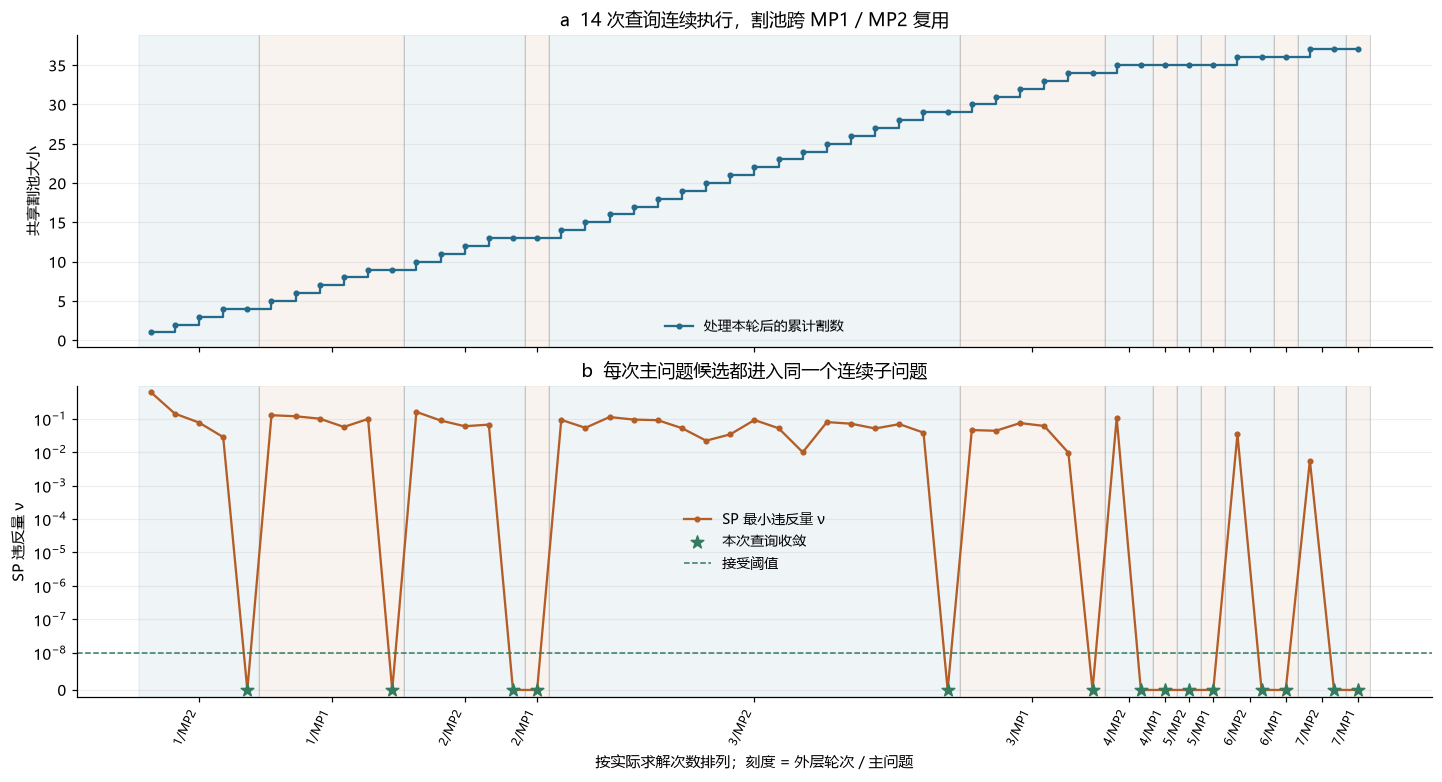

,query_number,outer_round,phase,query,query_unit,value,value_unit,master_solves,new_cuts,inherited_cuts,status
0,1,1,MP2,193780.000000,CNY,2.375000,lambda,5,4,0,optimal
1,2,1,MP1,2.375000,lambda,56300.000000,CNY,6,5,4,optimal
2,3,2,MP2,56280.000000,CNY,2.011144,lambda,5,4,9,optimal
3,4,2,MP1,2.011144,lambda,51020.000000,CNY,1,0,13,optimal
4,5,3,MP2,51000.000000,CNY,1.666667,lambda,17,16,13,optimal
5,6,3,MP1,1.666667,lambda,41600.000000,CNY,6,5,29,optimal
6,7,4,MP2,41580.000000,CNY,1.566887,lambda,2,1,34,optimal
7,8,4,MP1,1.566887,lambda,32360.000000,CNY,1,0,35,optimal
8,9,5,MP2,32340.000000,CNY,1.227380,lambda,1,0,35,optimal
9,10,5,MP1,1.227380,lambda,14300.000000,CNY,1,0,35,optimal


In [15]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True, layout='constrained')
centers, tick_labels = [], []
for qid, part in combined_trace.groupby('query_number', sort=True):
    phase, outer_round = part.phase.iloc[0], int(part.outer_round.iloc[0])
    lo, hi = part.global_iteration.min()-.5, part.global_iteration.max()+.5
    color = BLUE if phase == 'MP2' else ORANGE
    centers.append((lo+hi)/2)
    tick_labels.append(f'{outer_round}/{phase}')
    for ax in axes:
        ax.axvspan(lo, hi, color=color, alpha=.07)
        ax.axvline(hi, color=GRAY, lw=.5, alpha=.4)
axes[0].step(combined_trace.global_iteration, combined_trace.cut_count_after,
             where='post', color=BLUE, marker='.', label='处理本轮后的累计割数')
axes[0].set(ylabel='共享割池大小', title='a  14 次查询连续执行，割池跨 MP1 / MP2 复用')
axes[0].legend(fontsize=9)
axes[1].plot(combined_trace.global_iteration, combined_trace.violation, '.-', color=ORANGE,
             label='SP 最小违反量 ν')
accepted = combined_trace.action == 'accept'
axes[1].scatter(combined_trace.loc[accepted,'global_iteration'], combined_trace.loc[accepted,'violation'],
                color=GREEN, marker='*', s=75, label='本次查询收敛', zorder=4)
axes[1].axhline(config.feasibility_tolerance, color=GREEN, ls='--', lw=1, label='接受阈值')
axes[1].set_yscale('symlog', linthresh=1e-8)
axes[1].set_ylim(-2e-9, max(combined_trace.violation.max()*1.5, 1e-7))
axes[1].set(ylabel='SP 违反量 ν', xlabel='按实际求解次数排列；刻度 = 外层轮次 / 主问题',
            title='b  每次主问题候选都进入同一个连续子问题')
axes[1].set_xticks(centers, tick_labels, rotation=65, ha='right', fontsize=8)
axes[1].legend(fontsize=9)
for ax in axes: ax.grid(axis='y', alpha=.2)
save_learning_figure(fig, '05_shared_cut_timeline')
plt.show()
display(queries)

### 5.3 每次查询各自的上下界：左列 MP2，右列 MP1

每行是一轮外层递推，横轴重新从本次查询的第 1 次主问题求解计数。
蓝线为 LB，橙线为 UB；仅绘有限值，右列标明仍为无穷大的阶段。
一轮收敛只证明**当前查询**最优，前沿完成则要求外层也达到停止条件。

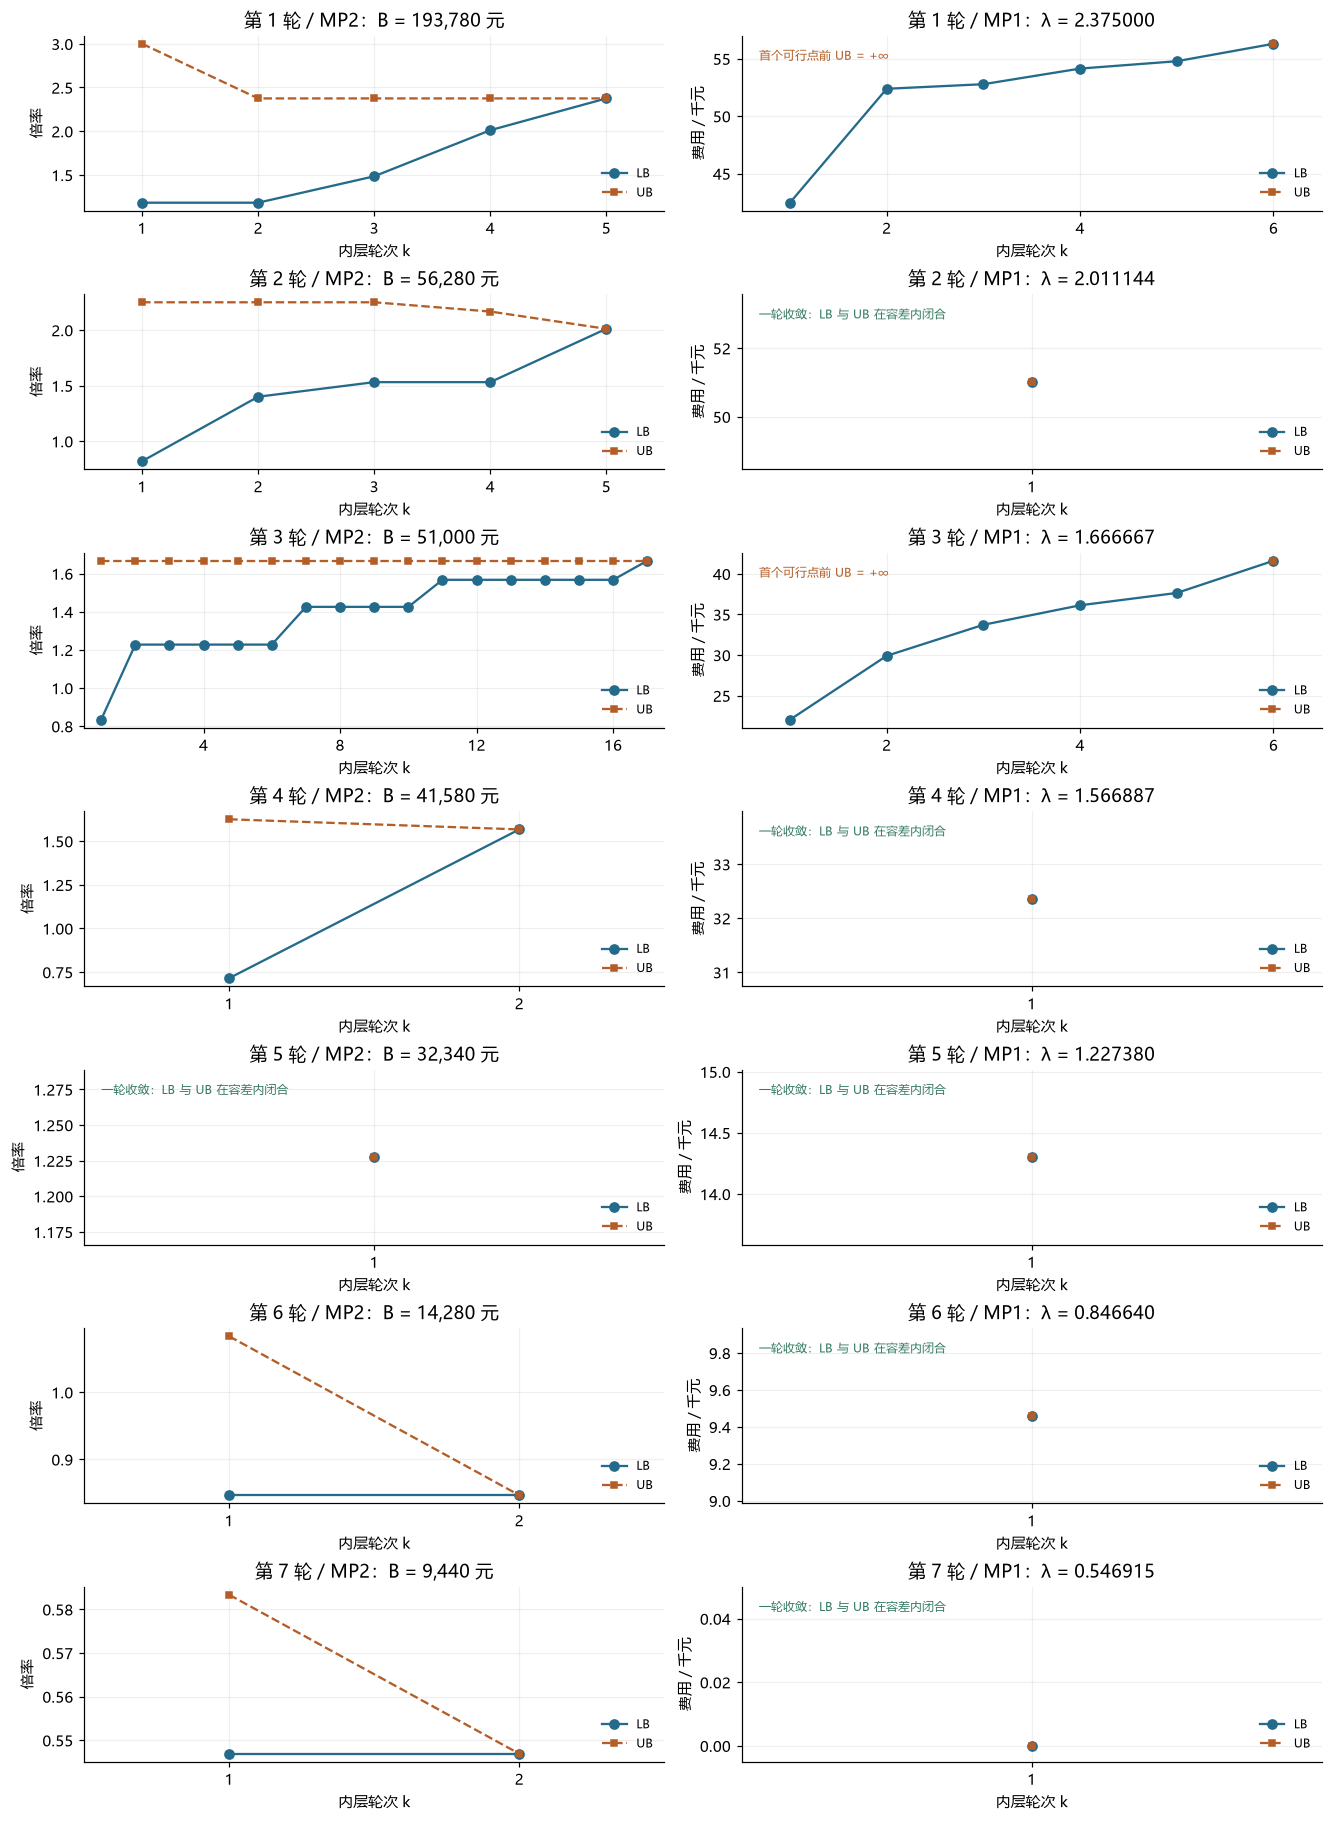

In [16]:
fig, axes = plt.subplots(len(outer), 2, figsize=(12, 2.35*len(outer)), squeeze=False, layout='constrained')
for i, result in enumerate(query_history):
    ax = axes[i//2, i%2]
    tr = result.trace
    scale = 1 if result.mode == 'max_lambda' else 1000
    ax.plot(tr.iteration, tr.lower_bound/scale, 'o-', color=BLUE, ms=6, label='LB')
    ax.plot(tr.iteration, tr.upper_bound.where(np.isfinite(tr.upper_bound))/scale,
            's--', color=ORANGE, ms=4, label='UB')
    if np.isinf(tr.upper_bound).any():
        ax.text(.03,.92,'首个可行点前 UB = +∞', transform=ax.transAxes, va='top', fontsize=8, color=ORANGE)
    phase = 'MP2' if result.mode == 'max_lambda' else 'MP1'
    query_label = f'B = {result.query:,.0f} 元' if phase == 'MP2' else f'λ = {result.query:.6f}'
    ax.set(title=f'第 {i//2+1} 轮 / {phase}：{query_label}',
           xlabel='内层轮次 k', ylabel='倍率' if phase == 'MP2' else '费用 / 千元')
    ax.ticklabel_format(axis='y', style='plain', useOffset=False)
    ax.set_xlim(.5, tr.iteration.max()+.5)
    finite_values = np.r_[tr.lower_bound, tr.upper_bound] / scale
    finite_values = finite_values[np.isfinite(finite_values)]
    if np.ptp(finite_values) < 1e-6:
        center = float(np.mean(finite_values))
        pad = max(abs(center)*.05, .05)
        ax.set_ylim(max(center-pad, -.1*pad), center+pad)  # 不放大浮点残差；零费用处留少量标记空间。
        ax.text(.03, .92, '一轮收敛：LB 与 UB 在容差内闭合',
                transform=ax.transAxes, va='top', fontsize=8, color=GREEN)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
    if len(tr) == 1:
        ax.set_xticks([1])
    ax.grid(alpha=.2)
    ax.legend(loc='lower right', fontsize=8)
save_learning_figure(fig, '06_all_query_bounds')
plt.show()

### 5.4 逐轮回放入口

将下面的 `ROUND_TO_INSPECT` 改成 1–7，可读取那一轮 MP2 和 MP1 的全部候选与割。
所有轮次的完整表格也已保存到 `alternating_all_iterations.csv`。

In [17]:
ROUND_TO_INSPECT = 1
assert 1 <= ROUND_TO_INSPECT <= len(outer)
for result in query_history[2*(ROUND_TO_INSPECT-1):2*ROUND_TO_INSPECT]:
    display(Markdown('**MP2 + SP**' if result.mode == 'max_lambda' else '**MP1 + SP**'))
    show_trace(result)

**MP2 + SP**

,内层轮次,已有割数,候选费用/元,候选倍率,该方案可达倍率,SP违反量,目标下界,目标上界,绝对间隙,新增割编号,处理,候选方案
0,1,0,58340.0,3.000,1.182284,0.625000,1.182284,3.000,1.817716,1.0,加割后重求,12:M; 02:H; 23:H
1,2,1,58340.0,2.375,1.182284,0.141667,1.182284,2.375,1.192716,2.0,加割后重求,12:M; 02:H; 23:H
2,3,2,47300.0,2.375,1.484197,0.076690,1.484197,2.375,0.890803,3.0,加割后重求,01:H; 13:L; 02:H
3,4,3,57620.0,2.375,2.011144,0.028207,2.011144,2.375,0.363856,4.0,加割后重求,01:H; 13:M; 02:H
4,5,4,62900.0,2.375,2.375000,0.000000,2.375000,2.375,0.000000,NaN,可行，结束,01:H; 13:H; 02:H


**MP1 + SP**

,内层轮次,已有割数,候选费用/元,候选倍率,该方案可达倍率,SP违反量,目标下界,目标上界,绝对间隙,新增割编号,处理,候选方案
0,1,4,42460.0,2.375,1.089291,0.127028,42460.0,inf,inf,5.0,加割后重求,01:M; 13:L; 02:H
1,2,5,52380.0,2.375,1.124755,0.118314,52380.0,inf,inf,6.0,加割后重求,01:H; 02:M; 23:L
2,3,6,52780.0,2.375,1.348631,0.100000,52780.0,inf,inf,7.0,加割后重求,01:M; 13:M; 02:H
3,4,7,54140.0,2.375,1.673272,0.056699,54140.0,inf,inf,8.0,加割后重求,01:M; 02:H; 23:L
4,5,8,54780.0,2.375,1.296358,0.098427,54780.0,inf,inf,9.0,加割后重求,01:H; 02:M; 23:M
5,6,9,56300.0,2.375,2.375000,0.000000,56300.0,56300.0,0.0,NaN,可行，结束,01:H; 13:H; 02:M


## 6. 前沿怎么保证完整？ε-约束、预算跳转与独立枚举

### 6.1 是 ε-约束法，但不是固定网格逐点扫描

多目标问题是“费用越小越好、倍率越大越好”。MP2 把费用目标转成 $C(x)\le B_j$，只优化倍率，
因此 $B_j$ 就是 ε-约束法中的可变右端参数。MP1 再对并列最大倍率的解做最小费用选择。
这里没有 AUGMECON 的松弛变量增强目标，不把本实现称为 AUGMECON。

默认费用系数都是整数元，其正数项的最大公约数为 $\delta_C=20$ 元，所以任何设计总费用都在 $20\mathbb Z$ 上。
**这是已知精确格点，不是人为选定的近似扫描步长。** 20 元也不是“相邻前沿点必差 20 元”；实际跳距通常很大。

为什么更新 $B_{j+1}=C_j-20$ 不漏台阶？

1. MP2 证明：预算不超过 $B_j$ 时，没有能力高于 $\lambda_j$ 的设计。
2. MP1 找到承载 $\lambda_j$ 的最低费用 $C_j$。在 $[C_j,B_j]$ 内，$\Lambda^*(B)$ 恒等于 $\lambda_j$，可整段跳过。
3. 剩下未搜索的方案必须满足 $C(x)<C_j$。由费用格点，这**等价于** $C(x)\le C_j-20$。
4. 从覆盖所有设计费用的预算开始；每轮严格下降；到下一预算为负或下一次主问题不可行时结束。

由此得到有限模型内全部非支配拐点。若费用带小数，应先换为精确的最小货币单位；
当前实现会拒绝非整数费用，避免悄悄取整后漏点。若搜索倍率上界低于电气上界，得到的也只是截断范围内的前沿。

本结论依赖本例的单调性：固定树时潮流与压降随 $\lambda$ 线性变化，设计可行倍率区间为 $[0,\Lambda(x)]$。
因此
$$\Lambda^*(B)=\max_{x:C(x)\le B}\Lambda(x),\qquad
C^*(\lambda)=\min_{x:\Lambda(x)\ge\lambda}C(x).$$
当 $C_i$ 严格递增时，$\Lambda^*(B)=\Lambda_i$ 对所有 $B\in[C_i,C_{i+1})$ 成立；
反过来，$C^*(\lambda)=C_i$ 对 $\lambda\in(\Lambda_{i-1},\Lambda_i]$ 成立。注意两个方向的开闭端点不同。

In [18]:
rounded_cost = np.rint(model.cost).astype(int)
quantum = math.gcd(*[int(c) for c in rounded_cost if c>0])
assert np.allclose(model.cost, rounded_cost, atol=1e-8, rtol=0)
assert quantum == 20
assert np.allclose(outer.next_budget_cny, outer.mp1_cost_cny-quantum, atol=1e-6, rtol=0)
assert np.all(outer.next_budget_cny < outer.budget_cny)
assert outer.iloc[-1].next_budget_cny < 0
print('费用精确粒度:', quantum, '元')
print('外层实际预算序列:', outer.budget_cny.astype(int).tolist())
print('终止时下一预算:', outer.iloc[-1].next_budget_cny)

费用精确粒度: 20 元
外层实际预算序列: [193780, 56280, 51000, 41580, 32340, 14280, 9440]
终止时下一预算: -20.0


### 6.2 独立真值：枚举 8 棵树 × 27 种线型 = 216 个设计

**前面的三个求解实验已完成，现在才引入完整枚举作为裁判。**
固定一棵树时，基准倍率下的支路流量等于子树负荷之和 $f_e$，节点累计平方电压降为 $\Delta_i$，因此
$$\Lambda(x)=\min\left\{\frac{S_{tr}\,PF}{\sum_i p_i^0},\ 
\min_{e\in x}\frac{\mathrm{cap}_e}{f_e},\ 
\min_i\frac{1-v_{min}}{\Delta_i}\right\}.$$
其中 $v_{min}=0.93^2$，不是 0.93。按费用升序排序，同费用先选能力高的，再只保留能力严格增加的方案。
这得到独立的完整阶梯。它不需要 Benders 割，也不参与前面主问题的选解。

In [19]:
designs = enumerate_designs(model)
exact_frontier = frontier_table(designs)
assert len(designs) == 216
assert len(recovered) == len(exact_frontier)
comparison = exact_frontier[['cost_cny','lambda_max']].merge(
    recovered[['cost_cny','lambda_max']], on='cost_cny', how='outer',
    suffixes=('_enumeration','_benders'), indicator=True)
assert (comparison['_merge'] == 'both').all()
comparison['absolute_error'] = abs(comparison.lambda_max_enumeration-comparison.lambda_max_benders)
assert comparison.absolute_error.max() < 2e-6
assert np.all(np.diff(exact_frontier.cost_cny)>0) and np.all(np.diff(exact_frontier.lambda_max)>0)
assert all(abs(z.cost_cny/quantum-round(z.cost_cny/quantum))<1e-8 for z in designs)
display(comparison.drop(columns='_merge'))
display(exact_frontier)
comparison.to_csv(OUTPUT / 'frontier_crosscheck.csv', index=False)

,cost_cny,lambda_max_enumeration,lambda_max_benders,absolute_error
0,0.0,0.546915,0.546915,0.000000e+00
1,9460.0,0.846640,0.846640,0.000000e+00
2,14300.0,1.227380,1.227380,2.220446e-16
3,32360.0,1.566887,1.566887,0.000000e+00
4,41600.0,1.666667,1.666667,0.000000e+00
5,51020.0,2.011144,2.011144,0.000000e+00
6,56300.0,2.375000,2.375000,0.000000e+00


,cost_cny,lambda_max,bottleneck,design
0,0.0,0.546915,voltage:2,01:L; 12:L; 13:L
1,9460.0,0.846640,voltage:2,01:M; 12:L; 13:L
2,14300.0,1.227380,voltage:2,01:H; 12:L; 13:L
3,32360.0,1.566887,voltage:2,01:H; 12:M; 13:M
4,41600.0,1.666667,capacity:01,01:H; 12:H; 13:H
5,51020.0,2.011144,voltage:3,01:H; 13:M; 02:M
6,56300.0,2.375000,transformer,01:H; 13:H; 02:M


### 6.3 对每个跳点做“左边、恰好、右边”检查

对每个 $C_i>0$，查询 $C_i-1$、$C_i$、$C_i+1$ 元（首点只查非负预算）。
由于所有设计费用都为 20 的倍数，减 1 元足以站到跳点左边；
这组**验证查询不用于发现前沿**。每个结果都与独立枚举一致，才说明台阶画在了正确位置。
另外在每段预算区间中点检查一次；完整性依据仍是上面的递推证明和全设计枚举，不是有限测试点本身。

In [20]:
boundary_cuts = shared_cuts.copy()
budget_checks = []
for point in exact_frontier.itertuples():
    for offset in (-1.0, 0.0, 1.0):
        budget = point.cost_cny+offset
        if budget < 0: continue
        expected = max(z.lambda_max for z in designs if z.cost_cny <= budget+1e-8)
        result = solve_by_cuts(model, 'max_lambda', budget, boundary_cuts)
        assert result.status == 'optimal' and abs(result.value-expected)<2e-6
        budget_checks.append({'jump_cost_cny': point.cost_cny, 'offset_cny':offset,
                              'budget_cny':budget, 'benders_lambda':result.value,
                              'enumerated_lambda':expected, 'absolute_error':abs(result.value-expected)})
for left, right in zip(exact_frontier.itertuples(), list(exact_frontier.itertuples())[1:]):
    result = solve_by_cuts(model, 'max_lambda', (left.cost_cny+right.cost_cny)/2, boundary_cuts)
    assert abs(result.value-left.lambda_max) < 2e-6
budget_checks = pd.DataFrame(budget_checks)
display(budget_checks)
budget_checks.to_csv(OUTPUT / 'jump_boundary_checks.csv', index=False)

# 反向再验证 C*(λ) 的右闭端点；增量小于任意相邻能力间隔。
lambda_checks = []
delta_lambda = min(1e-4, np.diff(exact_frontier.lambda_max).min()/10)
for point in exact_frontier.itertuples():
    for offset in (-delta_lambda, 0.0, delta_lambda):
        alpha = point.lambda_max+offset
        expected_candidates = [z.cost_cny for z in designs if z.lambda_max >= alpha-1e-8]
        expected = min(expected_candidates) if expected_candidates else math.inf
        result = solve_by_cuts(model, 'min_cost', alpha, boundary_cuts)
        assert (math.isinf(expected) and result.status=='infeasible') or abs(result.value-expected)<1e-4
        lambda_checks.append({'lambda':alpha, 'offset':offset, 'benders_cost':result.value,
                              'enumerated_cost':expected, 'status':result.status})
lambda_checks = pd.DataFrame(lambda_checks)
lambda_checks.to_csv(OUTPUT / 'lambda_boundary_checks.csv', index=False)
print(f'通过 {len(budget_checks)} 个预算跳点查询、{len(exact_frontier)-1} 个平台中点查询和 '
      f'{len(lambda_checks)} 个倍率端点查询。')

,jump_cost_cny,offset_cny,budget_cny,benders_lambda,enumerated_lambda,absolute_error
0,0.0,0.0,0.0,0.546915,0.546915,6.661338e-16
1,0.0,1.0,1.0,0.546915,0.546915,6.661338e-16
2,9460.0,-1.0,9459.0,0.546915,0.546915,6.661338e-16
3,9460.0,0.0,9460.0,0.846640,0.846640,1.110223e-16
4,9460.0,1.0,9461.0,0.846640,0.846640,1.110223e-16
5,14300.0,-1.0,14299.0,0.846640,0.846640,2.220446e-16
6,14300.0,0.0,14300.0,1.227380,1.227380,2.220446e-16
7,14300.0,1.0,14301.0,1.227380,1.227380,2.220446e-16
8,32360.0,-1.0,32359.0,1.227380,1.227380,2.227381e-10
9,32360.0,0.0,32360.0,1.566887,1.566887,1.887379e-14


通过 20 个预算跳点查询、6 个平台中点查询和 21 个倍率端点查询。


### 6.4 为什么粗扫描不够：同一数据上的反例

这里故意每 10,000 元采样一次，用完整枚举直接查出采样点处的正确能力，
从而排除“求解器没收敛”的干扰。粗网格仍可能**错放跳点位置，甚至完全漏掉短平台**。
它能提供截面样本，不能单凭连线证明完整前沿。

每 10,000 元扫描一次，本例漏掉了 **1 个平台高度**：

,cost_cny,lambda_max
5,51020.0,2.011144


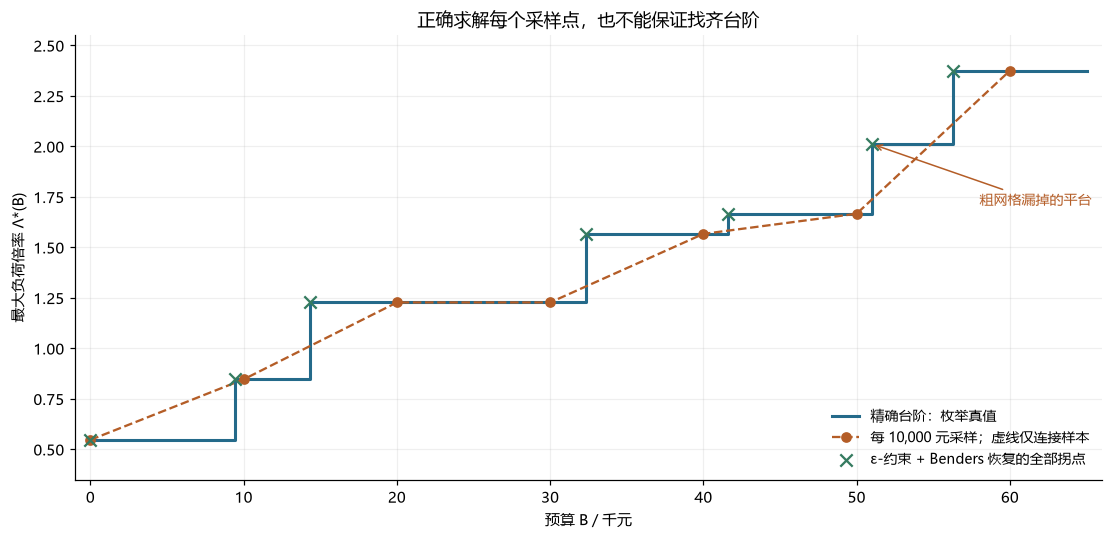

In [21]:
grid_budgets = np.arange(0.0, 70000.0, 10000.0)
grid_lambdas = np.array([max(z.lambda_max for z in designs if z.cost_cny<=b) for b in grid_budgets])
seen = [np.any(np.isclose(grid_lambdas, a, atol=1e-7, rtol=0)) for a in exact_frontier.lambda_max]
missed = exact_frontier.loc[~np.array(seen), ['cost_cny','lambda_max']]
display(Markdown(f'每 10,000 元扫描一次，本例漏掉了 **{len(missed)} 个平台高度**：'))
display(missed)
fig, ax = plt.subplots(figsize=(10, 4.8), layout='constrained')
costs = np.r_[exact_frontier.cost_cny.to_numpy(), 65000.0]
lambdas = np.r_[exact_frontier.lambda_max.to_numpy(), exact_frontier.lambda_max.iloc[-1]]
ax.step(costs/1000, lambdas, where='post', color=BLUE, lw=2, label='精确台阶：枚举真值')
ax.plot(grid_budgets/1000, grid_lambdas, 'o--', color=ORANGE,
        label='每 10,000 元采样；虚线仅连接样本')
ax.scatter(recovered.cost_cny/1000, recovered.lambda_max, marker='x', s=65, color=GREEN,
           label='ε-约束 + Benders 恢复的全部拐点', zorder=5)
for row in missed.itertuples():
    ax.annotate('粗网格漏掉的平台', xy=(row.cost_cny/1000, row.lambda_max),
                xytext=(row.cost_cny/1000+7, row.lambda_max-.3),
                arrowprops=dict(arrowstyle='->', color=ORANGE), color=ORANGE, fontsize=9)
ax.set(xlabel='预算 B / 千元', ylabel='最大负荷倍率 Λ*(B)', title='正确求解每个采样点，也不能保证找齐台阶',
       xlim=(-1,66), ylim=(.35,2.55))
ax.grid(alpha=.2)
ax.legend(loc='lower right', fontsize=9)
save_learning_figure(fig, '07_exact_frontier_vs_scan')
plt.show()

## 7. 对偶割与整数前沿：还有哪些需要核验？

### 7.1 全方案电气检查、查询检查与割有效性

保留原项目的完整回归实验：对 216 个设计的解析极限和稍微超限处各求一次 LP（共 432 次），
同时检查对偶可行性与强对偶；执行 8 个固定倍率、7 个固定预算查询，并再次恢复全部前沿。
此外，对本 notebook 新产生的所有割，检查它们在每个设计的可行倍率区间两端的值。
对固定 $x$，$g_t(x,\lambda)$ 关于 $\lambda$ 仿射，因此端点检查覆盖整段区间。

这些验证针对本线性模型；它们不能替代 AC 电网潮流复核。

In [22]:
experiment = run_experiment(OUTPUT / 'verification', config, model.lines, model.corridors)
all_learning_cuts = mp1_cuts + mp2_cuts + infeasible_cuts + boundary_cuts
worst_margin = validate_cuts(all_learning_cuts, designs)
assert np.allclose(experiment['frontier'].lambda_max, exact_frontier.lambda_max, atol=2e-6, rtol=0)
display(experiment['validation'])
display(pd.DataFrame([
    {'验证内容':'全部设计极限 / 超限 LP 检查', '数量':2*len(designs), '结果':'通过'},
    {'验证内容':'原项目固定倍率 / 固定预算查询', '数量':len(experiment['validation']), '结果':'通过'},
    {'验证内容':'两种独立方法恢复的台阶', '数量':len(recovered), '结果':'逐项一致'},
    {'验证内容':'教学实验累计割（含不同实验的重复割）', '数量':len(all_learning_cuts), '结果':'全部设计端点检查通过'},
]))
print('所有教学割的最小有效性余量:', worst_margin)

,mode,query,value,status
0,min_cost,0.4,0.000000e+00,optimal
1,min_cost,0.7,9.460000e+03,optimal
2,min_cost,1.0,1.430000e+04,optimal
3,min_cost,1.3,3.236000e+04,optimal
4,min_cost,1.6,4.160000e+04,optimal
5,min_cost,1.8,5.102000e+04,optimal
6,min_cost,2.1,5.630000e+04,optimal
7,min_cost,2.4,inf,infeasible
8,max_lambda,0.0,5.469151e-01,optimal
9,max_lambda,10000.0,8.466403e-01,optimal


,验证内容,数量,结果
0,全部设计极限 / 超限 LP 检查,432,通过
1,原项目固定倍率 / 固定预算查询,15,通过
2,两种独立方法恢复的台阶,7,逐项一致
3,教学实验累计割（含不同实验的重复割）,68,全部设计端点检查通过


所有教学割的最小有效性余量: -1.942890293094024e-16


### 7.2 二维凸包为什么仍不是这个整数规划域？

每个完整整数设计对应 $[C(x),\infty)\times[0,\Lambda(x)]$，完整预算域是这些矩形的并集。
把投影后的点做凸组合，可能得到一个没有任何整数设计可实现的预算—倍率点。
下面比较 $C^*(\lambda)$ 与**完整预算域的凸包**，后者不是某个特定 Big-M 写法的 LP 松弛。

所以可行性割是在保留 $x\in\{0,1\}^{15}$ 的主问题中工作；不能把“Benders 用线性割”理解为“最终规划域变成凸集”。

λ=1.1：整数最低费用 14,300.00 元；凸包下边界 11,623.11 元。


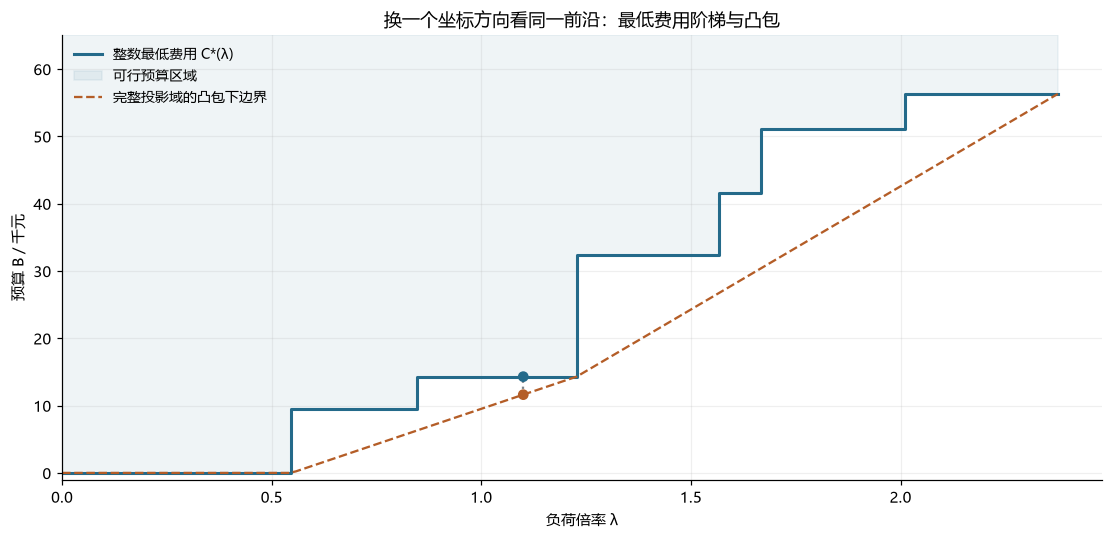

In [23]:
target = 1.1
true_cost = min(z.cost_cny for z in designs if z.lambda_max>=target)
hull_cost = float(convex_hull_cost(exact_frontier, [target])[0])
print(f'λ={target}：整数最低费用 {true_cost:,.2f} 元；凸包下边界 {hull_cost:,.2f} 元。')
grid = np.linspace(0, exact_frontier.lambda_max.max(), 150)
hull = convex_hull_cost(exact_frontier, grid)
fig, ax = plt.subplots(figsize=(10, 4.8), layout='constrained')
xx = np.r_[0, exact_frontier.lambda_max]
yy = np.r_[0, exact_frontier.cost_cny]/1000
ax.step(xx, yy, where='pre', color=BLUE, lw=2, label='整数最低费用 C*(λ)')
ax.fill_between(xx, yy, 65, step='pre', color=BLUE, alpha=.07, label='可行预算区域')
ax.plot(grid, hull/1000, '--', color=ORANGE, label='完整投影域的凸包下边界')
ax.scatter([target,target], [true_cost/1000,hull_cost/1000], color=[BLUE,ORANGE], zorder=5)
ax.plot([target,target], [hull_cost/1000,true_cost/1000], ':', color=GRAY)
ax.set(xlabel='负荷倍率 λ', ylabel='预算 B / 千元', xlim=(0,2.48), ylim=(-1,65),
       title='换一个坐标方向看同一前沿：最低费用阶梯与凸包')
ax.grid(alpha=.2)
ax.legend(loc='upper left', fontsize=9)
save_learning_figure(fig, '08_integer_region_vs_hull')
plt.show()

### 7.3 割池如何改善其他预算处的外近似？

仅为展示，我们在每 5,000 元的预算采样点比较 0 条割、独立 MP2 收敛后的割、交替实验全部割。
这些是**仍保留整数变量的受限主问题上界**，不能称作已通过 SP 的可行能力。
查询预算会改变可行方案集合，即使某次查询已收敛，割池也不一定对每个其他预算都足够。
下面故意用散点和虚线表示采样结果，不把连线伪装成已经认证的完整边界。

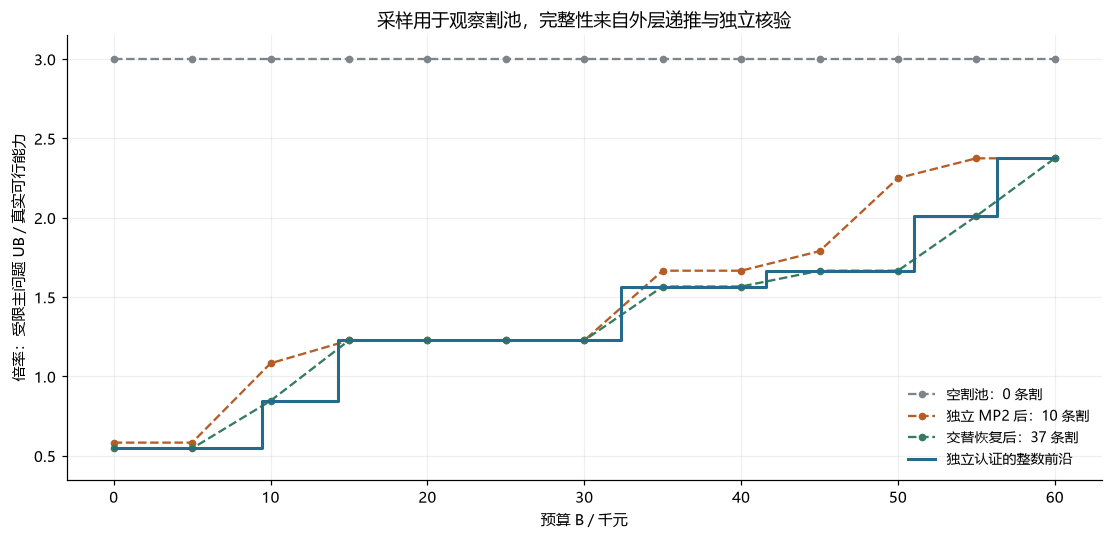

In [24]:
snapshot_rows = []
sample_budgets = np.arange(0.0, 60001.0, 5000.0)
stages = [('空割池', []), ('独立 MP2 后', mp2_cuts), ('交替恢复后', shared_cuts)]
fig, ax = plt.subplots(figsize=(10, 4.8), layout='constrained')
for (label, pool), color in zip(stages, (GRAY, ORANGE, GREEN)):
    values = []
    for budget in sample_budgets:
        master, _, _ = build_master(model, 'max_lambda', float(budget), pool)
        try:
            master.optimize()
            assert master.Status == gp.GRB.OPTIMAL
            value = master.ObjBound
        finally:
            master.dispose()
        exact = max(z.lambda_max for z in designs if z.cost_cny<=budget)
        assert value >= exact-2e-6
        values.append(value)
        snapshot_rows.append({'stage':label, 'cut_count':len(pool), 'budget_cny':budget,
                              'master_upper_bound':value, 'exact_lambda':exact})
    ax.plot(sample_budgets/1000, values, 'o--', ms=4, color=color, label=f'{label}：{len(pool)} 条割')
ax.step(np.r_[exact_frontier.cost_cny,60000]/1000,
        np.r_[exact_frontier.lambda_max,exact_frontier.lambda_max.iloc[-1]],
        where='post', lw=2, color=BLUE, label='独立认证的整数前沿')
ax.set(xlabel='预算 B / 千元', ylabel='倍率：受限主问题 UB / 真实可行能力', ylim=(.35,3.15),
       title='采样用于观察割池，完整性来自外层递推与独立核验')
ax.legend(fontsize=9)
ax.grid(alpha=.2)
save_learning_figure(fig, '09_cut_pool_snapshots')
plt.show()
pd.DataFrame(snapshot_rows).to_csv(OUTPUT / 'sampled_cut_bounds.csv', index=False)

## 8. 带着四个问题复盘，并动手改参数

1. **MP1 + SP**：固定倍率，费用 LB 逐步收紧；SP 首次可行时得到同值 UB。它使用 Benders 可行性割。
2. **MP2 + SP**：固定预算，倍率 UB 逐步降低；已经访问的可行设计给 LB；接受时上下界闭合。
3. **两者交替**：MP2 求能力，MP1 压费用，SP 给两者提供同一类可复用的电气割。内层证明每次查询最优，外层找齐前沿点。
4. **检查台阶**：自适应 ε-约束递推发现；完整枚举独立核验；跳点左右查询检查端点；预算采样只帮助观察。

建议按顺序做三个小实验：

- 把 `MP1_TARGET_LAMBDA` 改成 1.1 / 1.6，比较访问过的建设方案和新增割数量；先预测费用会在哪个台阶。
- 把 `MP2_BUDGET_CNY` 改成 32,359 / 32,360 / 32,361，验证只差 1 元如何跨过跳点。
- 把粗扫描间隔由 10,000 改成 5,000；观察即使碰到了全部平台高度，网格仍未必给出精确跳点费用。

每次改查询参数后建议从头运行。若修改线路、费用或电气参数，也要重建模型并清空割池；
本 notebook 的“216、20、2.4”等断言专门服务于默认算例，修改模型后应同步调整验证条件。

### 可追溯到实现

下方折叠区域是**当前运行所用函数的真实源码**，便于将表格里的每一步与代码对上。
`build_master` 构建 MP1/MP2，`feasibility_oracle` 求 SP 和 π，`solve_by_cuts` 执行内层，
`discover_frontier_by_cuts` 执行外层。完整公式编号保留在 [README](README.md)。

In [25]:
for function in (build_master, feasibility_oracle, solve_by_cuts, discover_frontier_by_cuts):
    display(HTML(f'<details><summary><b>{function.__name__}</b>：展开当前源码</summary>'
                 f'<pre style="white-space:pre-wrap;font-size:12px">'
                 f'{html.escape(inspect.getsource(function))}</pre></details>'))

### 方法来源

- [SCIP：Benders 分解框架](https://www.scipopt.org/doc/html/BENDDECF.php)：主问题、连续子问题以及可行性/最优性割的框架。
- [Gurobi：线性约束 Pi 属性](https://docs.gurobi.com/projects/optimizer/en/current/reference/attributes/constraintlinear.html#pi)：乘子的方向与可用条件。
- [Mavrotas (2009)，Effective implementation of the ε-constraint method](https://doi.org/10.1016/j.amc.2009.03.037)：将其他目标转为约束并改变其右端的 ε-约束方法背景；本 notebook 使用费用格点和先能力后费用的递推，没有实现 AUGMECON 的增强目标。

上述来源解释通用方法；本例“不漏台阶”的具体依据是第 6 节给出的费用格点、单调性和全模型核验。

In [26]:
summary = {
    'mp1': {'target_lambda':mp1.query, 'cost_cny':mp1.value, 'master_solves':len(mp1.trace), 'new_cuts':mp1.new_cuts},
    'mp2': {'budget_cny':mp2.query, 'lambda_max':mp2.value, 'master_solves':len(mp2.trace), 'new_cuts':mp2.new_cuts},
    'alternating': {'rounds':len(outer), 'queries':len(queries), 'master_solves':len(combined_trace),
                    'cuts':len(shared_cuts), 'cost_quantum_cny':quantum},
    'validation': {'designs':len(designs), 'frontier_steps':len(recovered),
                   'max_frontier_error':float(comparison.absolute_error.max()),
                   'budget_boundary_checks':len(budget_checks), 'lambda_boundary_checks':len(lambda_checks),
                   'worst_cut_margin':worst_margin, 'coarse_scan_missed_plateaus':len(missed)},
    'python_version':platform.python_version(), 'gurobi_version':list(gp.gurobi.version()),
    'model_scope':'lossless fixed-PF linear squared-voltage model; no AC validation',
}
(OUTPUT / 'learning_summary.json').write_text(json.dumps(summary, ensure_ascii=False, indent=2, allow_nan=False), encoding='utf-8')
print('全部计算与核验完成。结果保存于:', OUTPUT.resolve())
print('查看逐轮过程：mp1_trace.csv / mp2_trace.csv / alternating_all_iterations.csv')
print('查看前沿证据：frontier_crosscheck.csv / jump_boundary_checks.csv / lambda_boundary_checks.csv')
experiment['model'].subproblem.dispose()
model.subproblem.dispose()

全部计算与核验完成。结果保存于: C:\Users\10856\Desktop\GithubProject\PlanRegion\notebook_results\learning
查看逐轮过程：mp1_trace.csv / mp2_trace.csv / alternating_all_iterations.csv
查看前沿证据：frontier_crosscheck.csv / jump_boundary_checks.csv / lambda_boundary_checks.csv
